
# Complexidade de Algoritmos (Big-O)

**Objetivo:** entender como analisar a eficiência de algoritmos e comparar o crescimento do custo (tempo e espaço) conforme o tamanho da entrada aumenta.


## Motivação: Por que complexidade importa?

- Computadores são rápidos, mas o *crescimento* do custo com o tamanho da entrada (n) pode explodir.
- Dois algoritmos que resolvem o mesmo problema podem ter eficiências muito diferentes.
- Complexidade ajuda a **prever escalabilidade** sem depender de hardware específico.


## Notações: O, Ω e Θ

- **O(g(n))** (*Big-O*): **limite superior** assintótico — pior caso (ou um limite superior genérico).  
- **Ω(g(n))** (*Ômega*): **limite inferior** assintótico — melhor caso.  
- **Θ(g(n))** (*Teta*): **limite apertado** — quando há limites superior e inferior do mesmo tipo.

> Regra prática: quando dizemos “o algoritmo é O(n log n)”, estamos descrevendo como o **custo máximo** cresce com *n*.


## Medidas: Tempo × Espaço

- **Tempo:** número de operações elementares (comparações, atribuições, etc.).  
- **Espaço:** memória extra utilizada além da entrada (por exemplo, pilha de recursão, vetores auxiliares).
- Para análise assintótica, focamos no **termo dominante** e **ignoramos constantes**.


## Classes de complexidade e intuição visual

- **O(1) — constante:** custo não depende de *n* (ex.: acessar `arr[i]`).  
- **O(log n) — logarítmica:** dividir o problema pela metade a cada passo (ex.: **busca binária**).  
- **O(n) — linear:** visitar todos os elementos uma vez (ex.: **busca linear**).  
- **O(n log n) — quase linear:** dividir + conquistar com intercalamento/merge (ex.: **mergesort**, **quicksort** típico).  
- **O(n²) — quadrática:** duplo laço aninhado (ex.: **bubble sort**, **insertion sort**).  
- **O(2^n), O(n!) — exponencial/fatorial:** explodem rapidamente (ex.: força bruta de subconjuntos, **viajante** com permutações).


## Gráficos comparativos (crescimento assintótico)

Os gráficos abaixo mostram como diferentes funções de complexidade crescem à medida que *n* aumenta.  
> Observação: usamos escalas e limites diferentes para manter o gráfico legível.


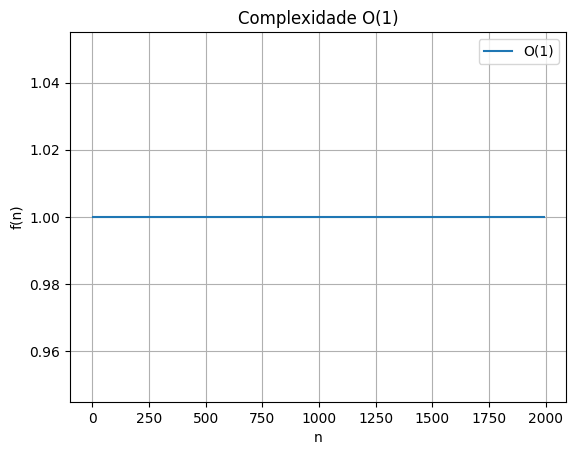

In [2]:
# O(1)
import matplotlib.pyplot as plt

ns = list(range(1, 2001, 10))
o1 = [1 for _ in ns]

plt.figure()
plt.plot(ns, o1, label="O(1)")
plt.title("Complexidade O(1)")
plt.xlabel("n")
plt.ylabel("f(n)")
plt.grid(True)
plt.legend()
plt.show()


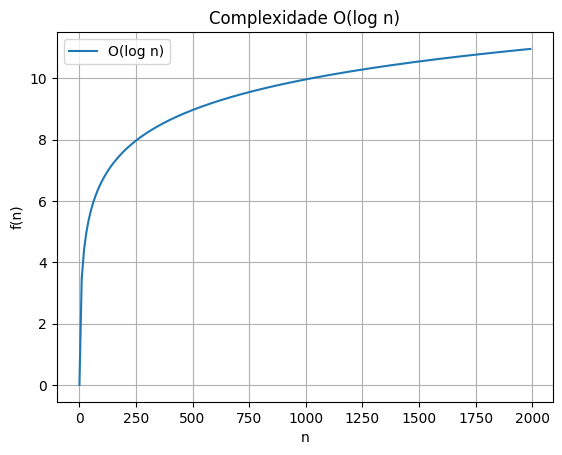

In [3]:
# O(log n)
import math
import matplotlib.pyplot as plt

ns = list(range(1, 2001, 10))
ologn = [math.log2(n) for n in ns]

plt.figure()
plt.plot(ns, ologn, label="O(log n)")
plt.title("Complexidade O(log n)")
plt.xlabel("n")
plt.ylabel("f(n)")
plt.grid(True)
plt.legend()
plt.show()


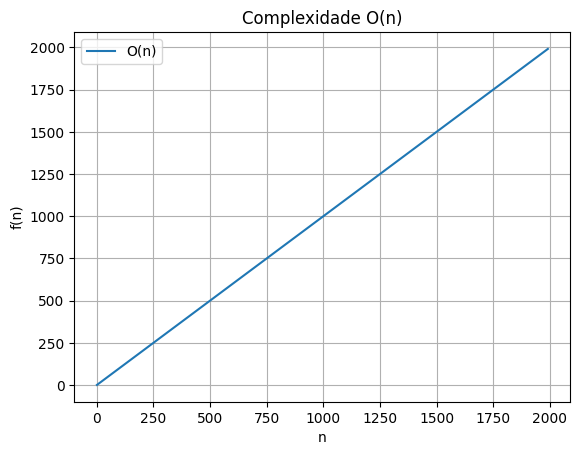

In [4]:
# O(n)
import matplotlib.pyplot as plt

ns = list(range(1, 2001, 10))
on = [n for n in ns]

plt.figure()
plt.plot(ns, on, label="O(n)")
plt.title("Complexidade O(n)")
plt.xlabel("n")
plt.ylabel("f(n)")
plt.grid(True)
plt.legend()
plt.show()


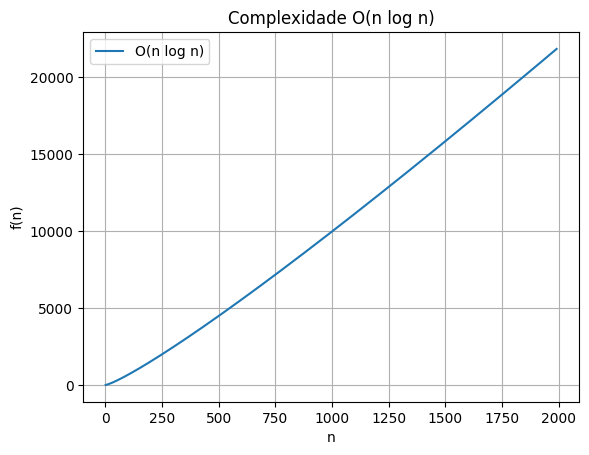

In [5]:
# O(n log n)
import math
import matplotlib.pyplot as plt

ns = list(range(1, 2001, 10))
onlogn = [n * math.log2(n) for n in ns]

plt.figure()
plt.plot(ns, onlogn, label="O(n log n)")
plt.title("Complexidade O(n log n)")
plt.xlabel("n")
plt.ylabel("f(n)")
plt.grid(True)
plt.legend()
plt.show()


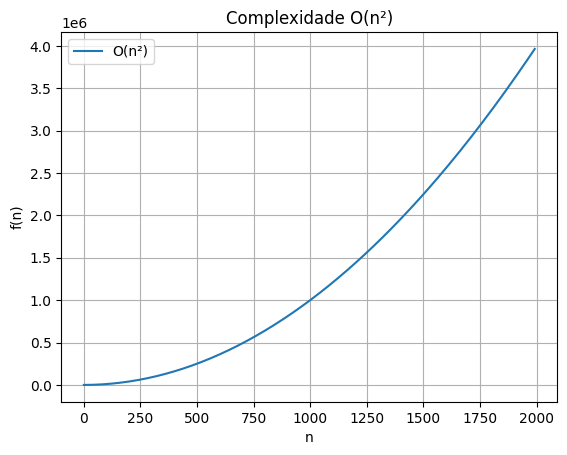

In [6]:
# O(n^2)
import matplotlib.pyplot as plt

ns = list(range(1, 2001, 10))
on2 = [n * n for n in ns]

plt.figure()
plt.plot(ns, on2, label="O(n²)")
plt.title("Complexidade O(n²)")
plt.xlabel("n")
plt.ylabel("f(n)")
plt.grid(True)
plt.legend()
plt.show()


Para complexidades **exponenciais** e **fatoriais**, precisamos limitar ainda mais o eixo **n** para visualizar:


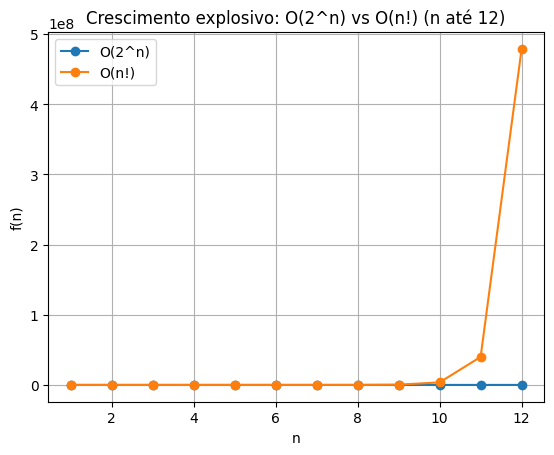

In [7]:

# Gráfico 2: O(2^n) e O(n!)
import math
import matplotlib.pyplot as plt

ns = list(range(1, 13))  # 1..12
o2n = [2**n for n in ns]
onf = [math.factorial(n) for n in ns]

plt.figure()
plt.plot(ns, o2n, marker='o', label="O(2^n)")
plt.plot(ns, onf, marker='o', label="O(n!)")
plt.title("Crescimento explosivo: O(2^n) vs O(n!) (n até 12)")
plt.xlabel("n")
plt.ylabel("f(n)")
plt.legend()
plt.grid(True)
plt.show()


## Exemplos práticos em Python

### Busca linear — O(n)
Percorre a lista até encontrar o elemento (ou esgotar).  
**Pior caso:** elemento não está na lista ⇒ precisa olhar tudo.


In [ ]:

def busca_linear(arr, alvo):
    for i, x in enumerate(arr):
        if x == alvo:
            return i
    return -1

# Teste rápido
dados = list(range(0, 100, 2))  # [0,2,4,...,98]
print("Posição do 42:", busca_linear(dados, 42))
print("Posição do 99 (não existe):", busca_linear(dados, 99))


### Busca binária — O(log n)
Requer coleção **ordenada**. A cada passo, descarta metade dos elementos restantes.


In [ ]:

def busca_binaria(arr, alvo):
    ini, fim = 0, len(arr)-1
    while ini <= fim:
        meio = (ini + fim) // 2
        if arr[meio] == alvo:
            return meio
        elif arr[meio] < alvo:
            ini = meio + 1
        else:
            fim = meio - 1
    return -1

# Teste rápido
dados_ord = list(range(0, 100000, 3))  # ordenado
print("Posição do 3000:", busca_binaria(dados_ord, 3000))
print("Posição do 3001 (não existe):", busca_binaria(dados_ord, 3001))


### Ordenação por bolha (Bubble Sort) — O(n²)  
Compara pares adjacentes e "borbulha" o maior para o final em cada passada.


In [ ]:

def bubble_sort(arr):
    a = arr[:]  # copia para não modificar a original
    n = len(a)
    trocou = True
    while trocou:
        trocou = False
        for i in range(1, n):
            if a[i-1] > a[i]:
                a[i-1], a[i] = a[i], a[i-1]
                trocou = True
        n -= 1  # último elemento já está na posição
    return a

# Teste rápido
import random
amostra = [random.randint(0, 1000) for _ in range(10)]
print("Antes:", amostra)
print("Depois (bubble):", bubble_sort(amostra))
print("Depois (sorted):", sorted(amostra))


## Medição empírica com `timeit`

Vamos comparar, empiricamente, o tempo para:
- **Busca linear** vs **busca binária**;
- **Bubble sort** vs **`sorted()`** (Timsort, caso médio O(n log n)).

> Os tempos exatos variam por máquina/execução. O foco é a **tendência**.


In [ ]:

import timeit
import random

def medir_buscas(tamanhos, repeticoes=3):
    resultados_linear = []
    resultados_binaria = []
    for n in tamanhos:
        arr = list(range(n))
        alvo_present = n-1  # pior caso para linear
        t_linear = min(timeit.repeat(lambda: busca_linear(arr, alvo_present), number=1, repeat=repeticoes))
        t_binaria = min(timeit.repeat(lambda: busca_binaria(arr, alvo_present), number=100, repeat=repeticoes)) / 100.0
        resultados_linear.append(t_linear)
        resultados_binaria.append(t_binaria)
    return resultados_linear, resultados_binaria

tamanhos_busca = [10_000, 50_000, 100_000, 200_000, 400_000]
res_lin, res_bin = medir_buscas(tamanhos_busca)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(tamanhos_busca, res_lin, marker='o', label="Busca linear (O(n))")
plt.plot(tamanhos_busca, res_bin, marker='o', label="Busca binária (O(log n))")
plt.title("Comparação empírica: busca linear vs binária")
plt.xlabel("n")
plt.ylabel("Tempo (s) — menor de 3 repetições")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:

def medir_ordenacao(tamanhos, repeticoes=3):
    tempos_bubble = []
    tempos_sorted = []
    for n in tamanhos:
        base = [random.randint(0, 10_000) for _ in range(n)]
        t_bubble = min(timeit.repeat(lambda: bubble_sort(base), number=1, repeat=repeticoes))
        t_sorted = min(timeit.repeat(lambda: sorted(base), number=1, repeat=repeticoes))
        tempos_bubble.append(t_bubble)
        tempos_sorted.append(t_sorted)
    return tempos_bubble, tempos_sorted

tamanhos_ord = [200, 400, 800, 1200]  # manter pequeno, pois bubble é lento
tb, ts = medir_ordenacao(tamanhos_ord)

import matplotlib.pyplot as plt

plt.figure()
plt.plot(tamanhos_ord, tb, marker='o', label="Bubble sort (O(n²))")
plt.plot(tamanhos_ord, ts, marker='o', label="sorted() (Timsort ~ O(n log n))")
plt.title("Ordenação: Bubble vs sorted()")
plt.xlabel("n")
plt.ylabel("Tempo (s) — menor de 3 repetições")
plt.legend()
plt.grid(True)
plt.show()


## Dicas para análise assintótica

- Foque no **termo dominante** (por exemplo, `3n² + 2n + 5` ⇒ O(n²)).  
- Ignore **constantes** e **baixas ordens** ao descrever Big-O.  
- Analise **loops aninhados**: cada aninhamento tende a multiplicar o custo.  
- **Divide and conquer** costuma levar a O(n log n) (quando há divisão balanceada e trabalho linear para combinar).  
- Considere **melhor, pior e caso médio** quando fizer sentido.



## Checklist rápido

- [ ] Identifique o tamanho da entrada (*n*).  
- [ ] Conte as operações por bloco/loop.  
- [ ] Descubra o termo dominante.  
- [ ] Classifique em O(·).  
- [ ] Compare alternativas e prefira ordens menores quando possível.



---

### 💡 Experimente você também!
1. Altere os tamanhos em `tamanhos_busca` e `tamanhos_ord`.  
2. Teste seus próprios algoritmos (por exemplo, insertion sort) e compare.  
3. Meça **uso de memória** com `sys.getsizeof` e estruturas auxiliares.
